In [1]:
from notebook_utils import *

Select your checkpoint

In [7]:
path = pyrootutils.find_root(indicator=".project-root")
# run_path = Path("logs/PointBeV/effb4/vis1_r3/")
run_path = Path("logs/PointBeV/train/runs/2025-03-18_21-55-00/")
# ckpt_path = path / run_path / "checkpoints" / "38_69.ckpt"
ckpt_path = path / run_path / "checkpoints" / "last.ckpt"
config_path = "../" / run_path / ".hydra"
overrides_path = config_path / "overrides.yaml"
device = "cuda"

Load overrides

In [8]:
overrides = OmegaConf.load(overrides_path)
overrides = [v for v in overrides if len(v.split("/")) < 2]

Create the associated configuration file.

In [13]:
with initialize(version_base="1.3", config_path=str(config_path)):
    cfg = compose(
        config_name="config.yaml",
        return_hydra_config=True,
        overrides=overrides
        + [
            # "data.version=trainval",
            "data.version=mini",
            "data.batch_size=1",
            "data.valid_batch_size=1",
            
            # # Sparse evaluation
            # "model.net.sampled_kwargs.val_mode=regular_pillars",
            # "model.net.sampled_kwargs.patch_size=1",
            # "model.net.sampled_kwargs.valid_fine=True",
            # "model.net.sampled_kwargs.N_coarse=2000",
            # "model.net.sampled_kwargs.N_fine=dyna",
            # "model.net.sampled_kwargs.N_anchor=dyna",
            # "model.net.sampled_kwargs.fine_thresh=0.1",
            # "model.net.sampled_kwargs.fine_patch_size=9",
        ],
    )

    cfg.paths.root_dir = str(pyrootutils.find_root(indicator=".project-root"))
cfg.ckpt.path = ckpt_path

Create model

In [14]:
model = hydra.utils.instantiate(cfg.model)
ckpt = utils.get_ckpt_from_path(cfg.ckpt.path)
model = utils.load_state_model(
    model,
    ckpt,
    cfg.ckpt.model.freeze,
    cfg.ckpt.model.load,
    verbose=1,
)
model.to(device)
model.eval()
self = model.net

Loaded pretrained weights for efficientnet-b4
# -------- Backbone -------- #
EfficientNet exists and is loaded at weights_path /home/michael/Documents/Master Sem 2/PLR/PointBeV/backbones/efficientnet-b4-6ed6700e.pth
# --------- Weighting --------- #
Initialized weight: 
name / init / coeffs / requires_grad
bev/binimg/T0_P0               0.000      10.000     True
bev/centerness                 0.000      0.500      True
bev/offsets                    0.000      0.500      True

# --------- Losses --------- #
bev:
  binimg:
    T0_P0:
      BCELoss(
  (loss_fn): BCEWithLogitsLoss()
)
  centerness:
    SpatialLoss()
  offsets:
    SpatialLoss()

# --------- Metrics --------- #
metric_iou_Time_Pose:
  T0_P0:
    IoUMetric()

# ------ Prepare model ------ #

Loaded params: {'net.backbone': 3684705, 'net.neck': 412800, 'net.view_transform': 291977, 'net.decoder': 3622930, 'net.heads': 442884, 'net.coord_selector': 2000000, 'weighting.weight_dict': 3, 'dict_losses.bev': 1}
Total loaded param

Dataset

In [15]:
datamodule = hydra.utils.instantiate(cfg.data)
datamodule.val_shuffle = True
datamodule.setup()


NuScenesDataset: 81 samples. Split: val.
Needed records: [0]
Cam. T value / index: [0] / [0]
Cam. P value / index : [0] / [0]
BEV. T value / index: [0] / [0]
BEV. P value / index: [0] / [0]

NuScenesDataset: 323 samples. Split: train.
Needed records: [0]
Cam. T value / index: [0] / [0]
Cam. P value / index : [0] / [0]
BEV. T value / index: [0] / [0]
BEV. P value / index: [0] / [0]


Sampled data

In [16]:
data = next(iter(datamodule.val_dataloader()))
data = datamodule.on_after_batch_transfer(data, None)

In [17]:
imgs = data["imgs"].to(device)
rots = data["rots"].to(device)
trans = data["trans"].to(device)
intrins = data["intrins"].to(device)
bev_aug = data["bev_aug"].to(device)
egoTin_to_seq = data["egoTin_to_seq"].to(device)
egoTout_to_seq = data["egoTout_to_seq"].to(device)

Inference

In [18]:
with torch.inference_mode():
    with torch.no_grad():
        out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)

Class: EfficientNet
Inputs:
--> torch.Size([6, 3, 224, 480])
Outputs:
--> torch.Size([6, 56, 28, 60])
--> torch.Size([6, 160, 14, 30])

Class: AGPNeck
Inputs:
Outputs:
--> torch.Size([6, 128, 28, 60])

Class: CamProjector
Inputs:
Outputs:
--> torch.Size([1, 1, 6, 200, 8, 200, 3])
--> torch.Size([1, 1, 6, 200, 8, 200, 1])
--> torch.Size([1, 1, 200, 8, 200, 3])

Class: GridSampleVT
Inputs:
--> torch.Size([1, 6, 128, 28, 60])
Outputs:
--> torch.Size([40000, 128])
--> torch.Size([1, 1, 1, 200, 200])
--> torch.Size([40000, 3])

Class: SparseUNet
Inputs:
Outputs:

Class: BEVConvHead
Inputs:
Outputs:



Visualisation

/tmp/ipykernel_24168/3373234978.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


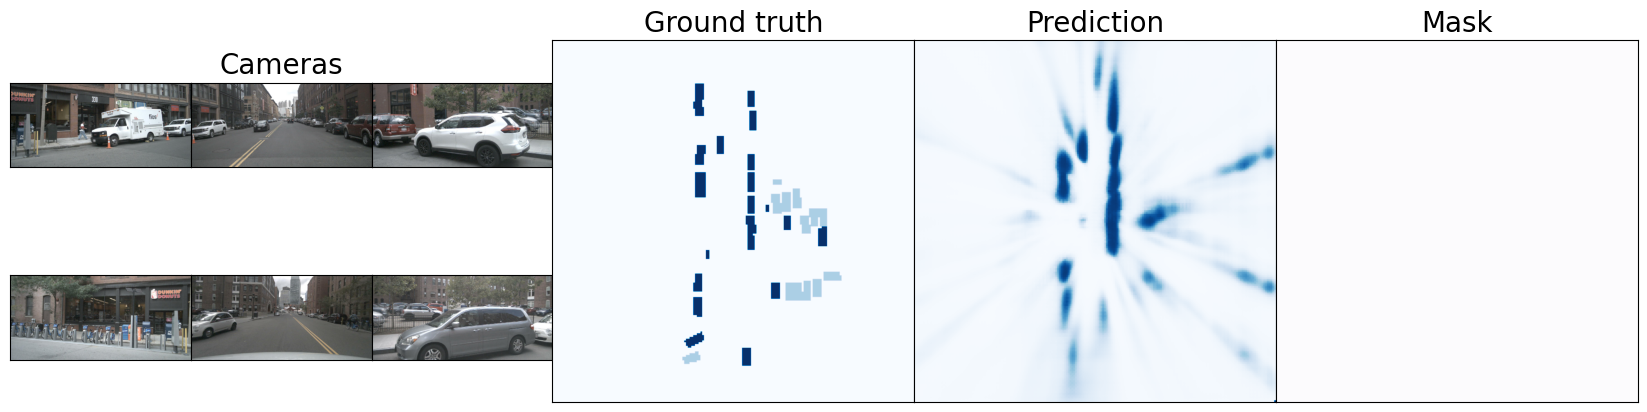

In [19]:
b_ts = 0
t_ts = 0
cmap = "Blues"


def visualise(imgs, data, out):
    key = "binimg"
    visibility = data.get("visibility", torch.ones_like(data[key]))
    
    # Prepare the images
    cam_imgs = [utils.imgs.DENORMALIZE_IMG(imgs[b_ts, t_ts, cam]) for cam in range(6)]
    bev_imgs = torch.cat(
        [
            # Ground truth
            (
                data[key]
                * ((visibility >= 2) * 2 + (visibility >= 1))
            )[b_ts, t_ts],
            # Prediction
            out["bev"][key][b_ts, t_ts].detach().cpu().sigmoid(),
            out["masks"]["bev"][key][b_ts, t_ts].detach().cpu(),
        ]
    )
    
    # Modify to keep the same color map:
    bev_imgs[1][0,0] = 0
    bev_imgs[1][-1,-1] = 1

    # Create figure and axes
    fig = plt.figure(figsize=(4.2 * 5, 1 * 5))  # Adjust figsize as needed

    num_cols = 3 + 6
    gs = gridspec.GridSpec(2, num_cols, figure=fig, wspace=0.0, hspace=0.0)

    # Create the axis
    axs = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(num_cols - 6)]

    # Cameras
    for idx, img in enumerate(cam_imgs):
        axs[idx].imshow(img)
        axs[idx].set_xticks([])
        axs[idx].set_yticks([])
    axs[1].set_title("Cameras", fontsize=20)

    # BeV
    ax_gt = fig.add_subplot(gs[0:2, 3:5])
    ax_gt.imshow(bev_imgs[0], cmap=cmap)

    ax_pred = fig.add_subplot(gs[0:2, 5:7])
    ax_pred.imshow(bev_imgs[1], cmap=cmap)
    
    ax_mask = fig.add_subplot(gs[0:2, 7:9])
    ax_mask.imshow(bev_imgs[2], cmap=matplotlib.cm.Purples)
    

    for ax, title in zip([ax_gt, ax_pred, ax_mask], ["Ground truth", "Prediction", "Mask"]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=20)

    return fig


# Show the plot
fig = visualise(imgs, data, out)
fig.show()

Create a clip

In [22]:
# Transform to convert PyTorch tensor to PIL image
transform = transforms.ToPILImage()

# Generating frames using the model
iter_loader = iter(datamodule.val_dataloader())

max_frames = 50

In [23]:
frames = []  # List to hold frames
frame_filenames = []

for frame_number in trange(max_frames):  # Iterate over your data
    input_data = next(iter_loader)
    data = datamodule.on_after_batch_transfer(input_data, None)

    imgs = data["imgs"].to(device)
    rots = data["rots"].to(device)
    trans = data["trans"].to(device)
    intrins = data["intrins"].to(device)
    bev_aug = data["bev_aug"].to(device)
    egoTin_to_seq = data["egoTin_to_seq"].to(device)
    egoTout_to_seq = data["egoTout_to_seq"].to(device)

    with torch.inference_mode():
        with torch.no_grad():
            out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)

    fig = visualise(imgs, data, out)
    frame_filename = f"frame_{frame_number}.png"
    plt.savefig(frame_filename, bbox_inches="tight")
    frame_filenames.append(frame_filename)
    plt.close()

# Create GIF from frames
frames = [Image.open(image) for image in frame_filenames]
frames[0].save(
    "../notebooks/test.gif",
    format="GIF",
    append_images=frames[1:],
    save_all=True,
    duration=1000,
    loop=0,
)

# Optional: Clean up by removing individual frame files
for filename in frame_filenames:
    os.remove(filename)

100%|██████████| 50/50 [00:47<00:00,  1.05it/s]
